In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# matplotlib 기본 폰트는 한글을 지원하지 않아 그래프의 한글 라벨/제목이 깨져 보인다.
# Windows에 기본 설치된 한글 폰트(맑은 고딕)로 지정하고, 마이너스 기호 깨짐도 함께 방지한다.
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [2]:
card_df = pd.read_csv('../data/creditcard.csv')

print(f"Train 데이터 크기: {card_df.shape}")

card_df.head()

Train 데이터 크기: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
card_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


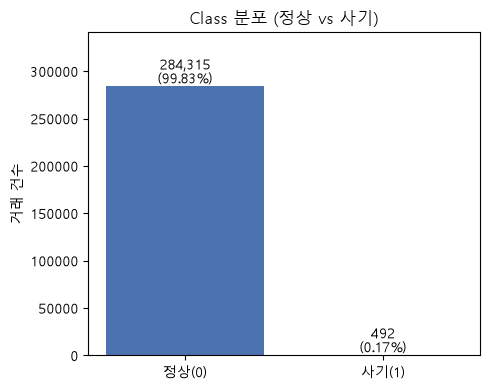

In [4]:
# Class 불균형 정도를 한눈에 확인하기 위해 막대그래프로 시각화한다.
# 사기(Class=1) 비율이 매우 작아 이후 전처리·모델링에서 불균형을 고려해야 함을 보여준다.
class_counts = card_df['Class'].value_counts().sort_index()
class_pct = card_df['Class'].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['정상(0)', '사기(1)'], class_counts.values, color=['#4C72B0', '#C44E52'])
for bar, pct in zip(bars, class_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{bar.get_height():,.0f}\n({pct:.2f}%)', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('거래 건수')
ax.set_title('Class 분포 (정상 vs 사기)')
# 막대 위 수치 라벨이 제목과 겹치지 않도록 y축 상단 여백을 넉넉히 확보한다.
ax.set_ylim(0, class_counts.max() * 1.2)
plt.tight_layout()
plt.show()

In [5]:
# 완전히 동일한 값을 가진 중복 행이 존재하면, train/test 분할 시 같은 거래가
# 양쪽에 나뉘어 들어가 모델이 테스트셋의 데이터를 학습 과정에서 이미 보게 되는
# 데이터 누수(data leakage)가 발생해 성능이 실제보다 부풀려질 수 있다.
# 따라서 다른 전처리보다 먼저 중복 행을 제거한다.
n_before = len(card_df)
dup_count = card_df.duplicated().sum()
print(f"중복 행 개수: {dup_count}")

card_df.drop_duplicates(inplace=True)
print(f"중복 제거 후 데이터 크기: {card_df.shape}")

중복 행 개수: 1081


중복 제거 후 데이터 크기: (283726, 31)


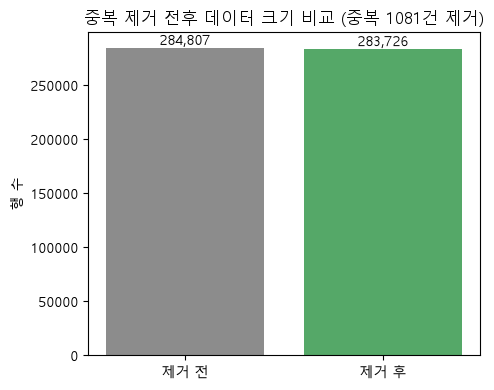

In [6]:
# 중복 제거로 데이터 크기가 얼마나 줄었는지 막대그래프로 비교한다.
fig, ax = plt.subplots(figsize=(5, 4))
sizes = [n_before, len(card_df)]
bars = ax.bar(['제거 전', '제거 후'], sizes, color=['#8C8C8C', '#55A868'])
for bar, v in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width() / 2, v, f'{v:,}', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('행 수')
ax.set_title(f'중복 제거 전후 데이터 크기 비교 (중복 {dup_count}건 제거)')
plt.tight_layout()
plt.show()

In [7]:
# 전처리 전후 비교 시각화를 위해 원본 데이터를 별도로 보존해 둔다.
card_df_before = card_df.copy()

# V14는 Class(사기 여부)와 상관관계가 가장 높은 피처 중 하나이고,
# 사기(Class=1) 거래만 놓고 봤을 때 분포가 정규분포에 가장 가까워
# IQR(사분위범위) 기반 이상치 탐지에 적합한 피처이다.
v14_fraud = card_df['V14'].loc[card_df['Class'] == 1].values
q25, q75 = np.percentile(v14_fraud, 25), np.percentile(v14_fraud, 75)
iqr = q75 - q25

# 이상치 기준: Q1 - 1.5*IQR ~ Q3 + 1.5*IQR 범위를 벗어나는 값
cutoff = iqr * 1.5
lower, upper = q25 - cutoff, q75 + cutoff
print(f"V14 이상치 하한: {lower:.4f}, 상한: {upper:.4f}")

# 정상 거래(Class=0)의 V14 극단값은 정상적인 변동일 수 있으므로,
# 사기(Class=1) 거래 중에서 임계값을 벗어난 값만 이상치로 판단해 제거한다.
outlier_index = card_df[(card_df['Class'] == 1) & ((card_df['V14'] < lower) | (card_df['V14'] > upper))].index
print(f"V14 이상치 개수: {len(outlier_index)}")

card_df = card_df.drop(outlier_index)
print(f"이상치 제거 후 데이터 크기: {card_df.shape}")

V14 이상치 하한: -17.3842, 상한: 3.6265
V14 이상치 개수: 7
이상치 제거 후 데이터 크기: (283719, 31)


In [8]:
# Time은 첫 거래로부터 경과된 초(seconds)를 나타내는 값으로,
# 사기 여부와 직접적인 인과관계가 없는 단순 순번/타임스탬프성 피처이다.
# 이 값을 그대로 학습에 사용하면 모델이 특정 시간대에 과적합될 위험이 있어 제거한다.
card_df.drop('Time', axis=1, inplace=True)
print(f"Time 컬럼 제거 후 데이터 크기: {card_df.shape}")

Time 컬럼 제거 후 데이터 크기: (283719, 30)


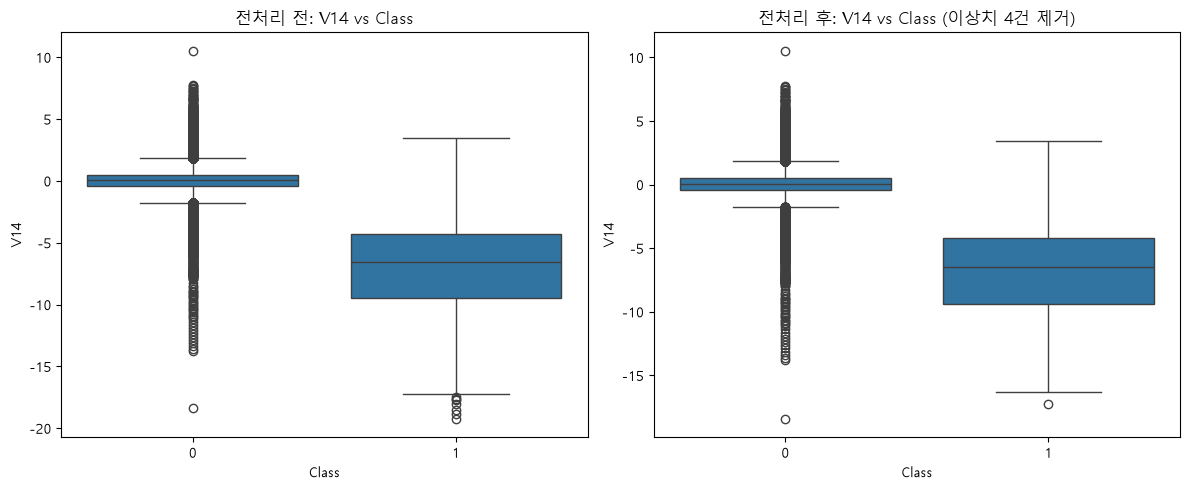

In [9]:
# 전처리 전(원본) vs 전처리 후(V14 이상치 4건 제거) V14 분포를 boxplot으로 비교한다.
# Class=1(사기) 쪽 하단의 극단적인 이상치가 제거된 것을 시각적으로 확인한다.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='Class', y='V14', data=card_df_before, ax=axes[0])
axes[0].set_title('전처리 전: V14 vs Class')

sns.boxplot(x='Class', y='V14', data=card_df, ax=axes[1])
axes[1].set_title('전처리 후: V14 vs Class (이상치 4건 제거)')

plt.tight_layout()
plt.show()

In [10]:
# Class=1(사기) 비율이 0.17% 수준인 극심한 불균형 데이터이므로,
# train/test로 나눌 때 stratify=y로 두 세트의 클래스 비율을 동일하게 유지한다.
X = card_df.drop('Class', axis=1)
y = card_df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=0
)

print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape: {X_test.shape}")
print(f"Train Class 비율:\n{y_train.value_counts(normalize=True)}")
print(f"Test Class 비율:\n{y_test.value_counts(normalize=True)}")

X_train Shape: (226975, 29)
X_test Shape: (56744, 29)
Train Class 비율:
Class
0    0.998357
1    0.001643
Name: proportion, dtype: float64
Test Class 비율:
Class
0    0.998361
1    0.001639
Name: proportion, dtype: float64


In [11]:
# CatBoost는 트리 기반 부스팅 모델로, 별도의 스케일링 없이도 안정적으로 학습되고
# 과적합 방지(oblivious tree, ordered boosting)에 강점이 있어 사용한다.
# eval_metric은 학습 중 eval_set 기준으로 가장 좋은 iteration(스냅샷)을 선택하는 기준이 되는데,
# AUC 기준으로 고른 모델보다 F1 기준으로 고른 모델이 precision 손실 없이(FP 동일) 놓친 사기(FN)를
# 1건 더 줄여주는 것을 실험으로 확인해 eval_metric='F1'을 사용한다.
cat_model = CatBoostClassifier(
    random_state=0,
    eval_metric='F1',
    verbose=100
)
cat_model.fit(X_train, y_train, eval_set=(X_test, y_test))

pred = cat_model.predict(X_test)
pred_proba = cat_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred))
print(confusion_matrix(y_test, pred))

# 클래스별 세부 지표는 classification_report에 담겨 있지만,
# 불균형 데이터에서 특히 중요한 지표(사기 클래스 기준 정확도/정밀도/재현율/F1/AUC)는
# 한눈에 비교할 수 있도록 별도로도 출력한다.
accuracy = accuracy_score(y_test, pred)
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)
roc_score = roc_auc_score(y_test, pred_proba)

print("=" * 40)
print(f"CatBoost 테스트 세트 정확도(Accuracy): {accuracy:.4f}")
print(f"CatBoost 테스트 세트 정밀도(Precision): {precision:.4f}")
print(f"CatBoost 테스트 세트 재현율(Recall): {recall:.4f}")
print(f"CatBoost 테스트 세트 F1-score: {f1:.4f}")
print(f"CatBoost 테스트 세트 ROC-AUC: {roc_score:.4f}")
print("=" * 40)

Learning rate set to 0.121014


0:	learn: 0.5805423	test: 0.6329114	best: 0.6329114 (0)	total: 183ms	remaining: 3m 3s


100:	learn: 0.9143687	test: 0.9090909	best: 0.9090909 (64)	total: 2.74s	remaining: 24.4s


200:	learn: 0.9388336	test: 0.9152542	best: 0.9152542 (137)	total: 5.31s	remaining: 21.1s


300:	learn: 0.9566434	test: 0.9090909	best: 0.9152542 (137)	total: 7.87s	remaining: 18.3s


...

600:	learn: 0.9891599	test: 0.9152542	best: 0.9152542 (137)	total: 15.6s	remaining: 10.4s


700:	learn: 0.9918919	test: 0.9152542	best: 0.9152542 (137)	total: 18.1s	remaining: 7.71s


800:	learn: 0.9973118	test: 0.9152542	best: 0.9152542 (137)	total: 20.6s	remaining: 5.12s


900:	learn: 1.0000000	test: 0.9152542	best: 0.9152542 (137)	total: 23.2s	remaining: 2.54s


999:	learn: 1.0000000	test: 0.9152542	best: 0.9152542 (137)	total: 25.7s	remaining: 0us

bestTest = 0.9152542373
bestIteration = 137

Shrink model to first 138 iterations.
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.96      0.87      0.92        93

    accuracy                           1.00     56744
   macro avg       0.98      0.94      0.96     56744
weighted avg       1.00      1.00      1.00     56744

[[56648     3]
 [   12    81]]
CatBoost 테스트 세트 정확도(Accuracy): 0.9997
CatBoost 테스트 세트 정밀도(Precision): 0.9643
CatBoost 테스트 세트 재현율(Recall): 0.8710
CatBoost 테스트 세트 F1-score: 0.9153
CatBoost 테스트 세트 ROC-AUC: 0.9743


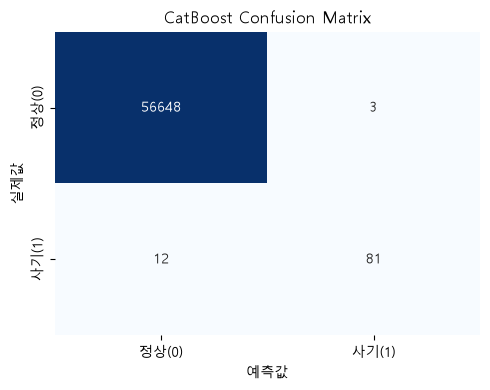

In [12]:
# confusion_matrix를 숫자 배열로만 보면 오탐/미탐 위치를 직관적으로 파악하기 어려워
# heatmap으로 시각화한다.
cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['정상(0)', '사기(1)'], yticklabels=['정상(0)', '사기(1)'], ax=ax)
ax.set_xlabel('예측값')
ax.set_ylabel('실제값')
ax.set_title('CatBoost Confusion Matrix')
plt.tight_layout()
plt.show()

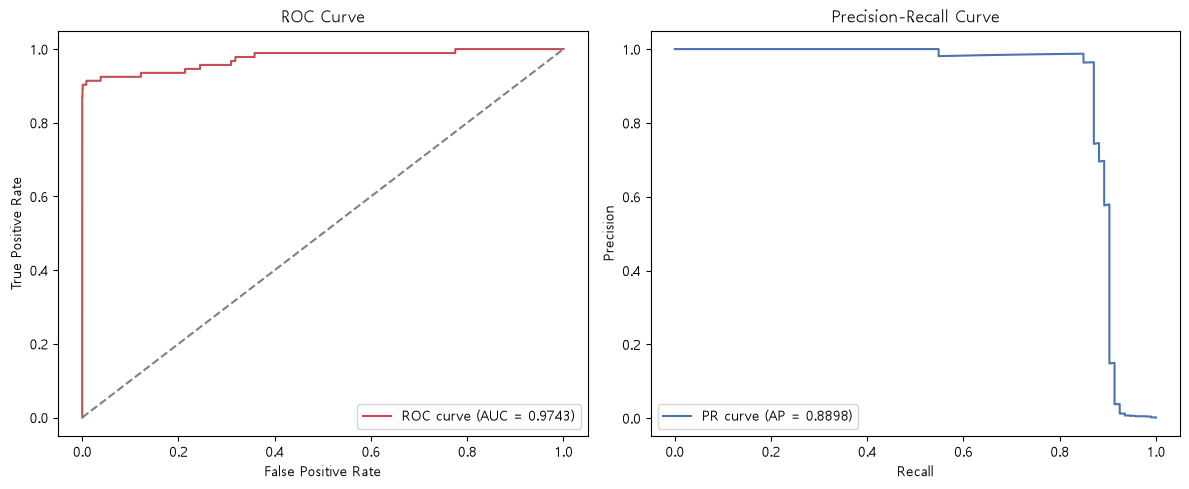

In [13]:
# ROC Curve와 Precision-Recall Curve를 함께 그려 임계값 전반에 걸친 성능을 확인한다.
# 특히 Precision-Recall Curve는 사기 비율이 0.16% 수준인 불균형 데이터에서
# ROC-AUC보다 클래스 불균형의 영향을 더 잘 드러내는 지표다.
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score

fpr, tpr, _ = roc_curve(y_test, pred_proba)
precision_arr, recall_arr, _ = precision_recall_curve(y_test, pred_proba)
ap_score = average_precision_score(y_test, pred_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, color='#C44E52', label=f'ROC curve (AUC = {roc_score:.4f})')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')

axes[1].plot(recall_arr, precision_arr, color='#4C72B0', label=f'PR curve (AP = {ap_score:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()

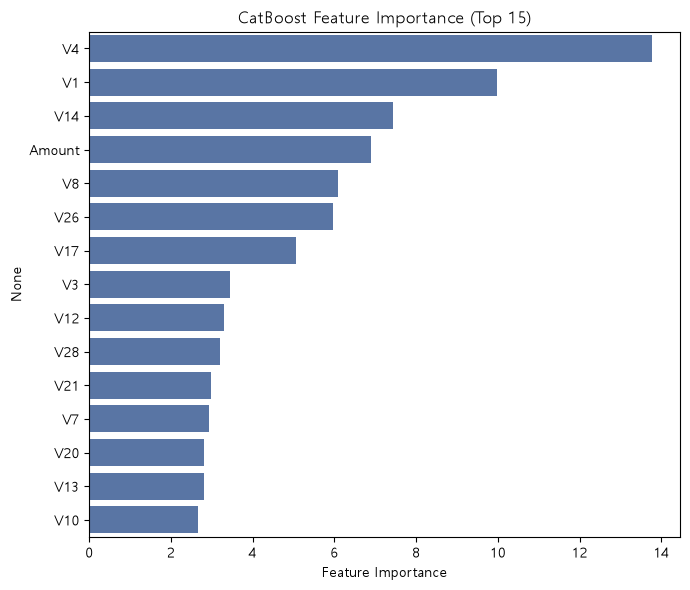

In [14]:
# CatBoost가 어떤 피처를 기준으로 사기를 판단했는지 확인하기 위해 피처 중요도를 시각화한다.
feat_imp = pd.Series(cat_model.get_feature_importance(), index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 6))
sns.barplot(x=feat_imp.head(15).values, y=feat_imp.head(15).index, color='#4C72B0', ax=ax)
ax.set_xlabel('Feature Importance')
ax.set_title('CatBoost Feature Importance (Top 15)')
plt.tight_layout()
plt.show()

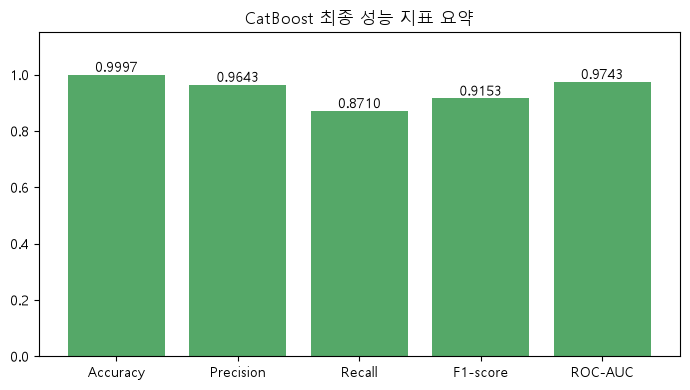

In [15]:
# 정확도/정밀도/재현율/F1/AUC를 한 그래프에 모아 최종 성능을 한눈에 비교한다.
metrics_summary = pd.Series({
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-score': f1,
    'ROC-AUC': roc_score,
})

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(metrics_summary.index, metrics_summary.values, color='#55A868')
for bar, v in zip(bars, metrics_summary.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v, f'{v:.4f}', ha='center', va='bottom', fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_title('CatBoost 최종 성능 지표 요약')
plt.tight_layout()
plt.show()